> # 📉 Customer Churn Prediction

## 🎯 Goal
Predict whether a customer is likely to churn using historical customer data.



## 💼 Business Objectives
- 📉 Reduce customer churn  
- ⚠️ Identify high-risk customers  
- 🎯 Enable targeted retention strategies

---

## 📚 Import Basic Libraries

In [1]:
# Let us import the basic required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


---

## 📥 Load Dataset

In [2]:
df=pd.read_excel("../dataset/Telco_customer_churn.xlsx")

---

## 🔍 Data Undetstanding

In [3]:
pd.set_option('display.max_columns',None)


In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.shape

(7043, 33)

In [6]:
df['Count'].value_counts()

# count Only have 1 value 

Count
1    7043
Name: count, dtype: int64

In [7]:
df['Country'].value_counts()

# Country Only have 1 value 


Country
United States    7043
Name: count, dtype: int64

In [8]:
for col in df.columns:
    if df[col].nunique() < 2:
        print(df[col].value_counts())

Count
1    7043
Name: count, dtype: int64
Country
United States    7043
Name: count, dtype: int64
State
California    7043
Name: count, dtype: int64


In [9]:
df['Zip Code'].nunique()

1652

---
> ### Observation-1
#### We do not need this cols
- CustomerId : As this one is not used in modeling and in analysis either 
- single valued cols: [ Count, Country , State ]
- Lat Long: we already have separete latitude and longitude cols
---

In [10]:
pd.set_option('display.max_rows',None)
df.groupby('City')['Zip Code'].nunique()

City
Acampo                     1
Acton                      1
Adelanto                   1
Adin                       1
Agoura Hills               1
Aguanga                    1
Ahwahnee                   1
Alameda                    2
Alamo                      1
Albany                     1
Albion                     1
Alderpoint                 1
Alhambra                   2
Aliso Viejo                1
Alleghany                  1
Alpaugh                    1
Alpine                     1
Alta                       1
Altadena                   1
Alturas                    1
Alviso                     1
Amador City                1
Amboy                      1
Anaheim                    7
Anderson                   1
Angels Camp                1
Angelus Oaks               1
Angwin                     1
Annapolis                  1
Antelope                   1
Antioch                    1
Anza                       1
Apple Valley               2
Applegate                  1
Aptos    

---
> ### Observation-2
- Most cities have only 1 zip code.
A few large cities have many.

| City          | Zip Codes |
| ------------- | --------- |
| Los Angeles   | 61        |
| San Diego     | 30        |
| San Jose      | 28        |
| San Francisco | 26        |
| Sacramento    | 27        |
| Fresno        | 16        |
| Long Beach    | 12        |
| Stockton      | 11        |
| Bakersfield   | 10        |
| Oakland       | 13        |

---
But ~90% of cities = 1 zip code.

---

 What this means for our dataset

- City and Zip Code are almost one-to-one.

 That means:

- City ≈ Zip Code

Keeping both adds redundant information.

In [11]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [12]:
df['Payment Method'].value_counts()

Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

<Axes: xlabel='Contract'>

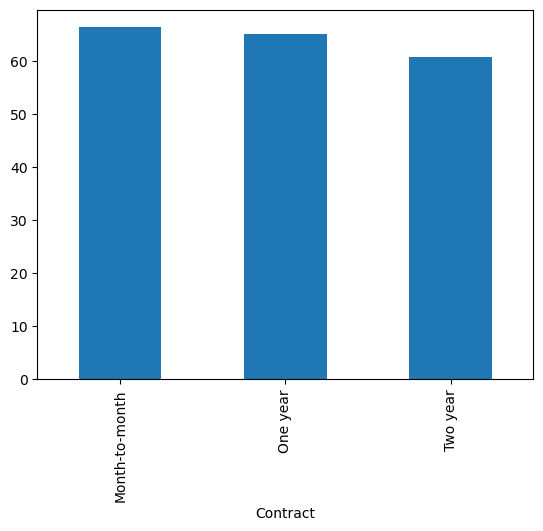

In [13]:
df.groupby('Contract')['Monthly Charges'].mean().plot(kind='bar')

In [14]:
for col in ['Churn Label','Churn Value']:
    print(df[col].value_counts())

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn Value
0    5174
1    1869
Name: count, dtype: int64


---
> ### Observation-3
- Churn Label and Churn Value Represent same thing 
 
 |Churn Label = 'Yes' | churn Label = 'No' |
 | -------------------|--------------      |
 |Churn Value = 1     | Churn Value = 1    |

- Keeping both adds redundant information.
---

In [15]:
df['Churn Reason'].value_counts()

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Limited range of services                     44
Long distance charges                         44
Lack of affordable download/upload speed      44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

> ### Observation-3

- **Churn Reason** is post-event information. It exists only after the customer has already churned. Using it in a churn prediction model causes data leakage.

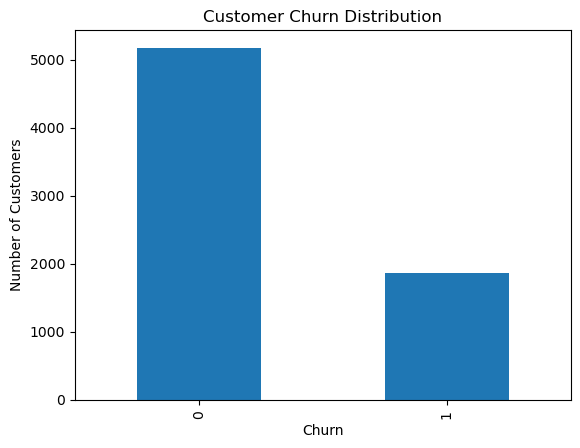

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [16]:

df['Churn Value'].value_counts().plot(kind='bar')

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

plt.show()

df['Churn Value'].value_counts()

In [17]:
churn_dist = df['Churn Value'].value_counts().to_frame(name='Count')
churn_dist['Percentage'] = (df['Churn Value'].value_counts(normalize=True)*100).round(2)
churn_dist

,Count,Percentage
Churn Value,,
0,5174,73.46
1,1869,26.54


> ## observation -4 
- The dataset shows a **moderate class imbalance** with approximately **73% non-churn** customers and **27% churn** customers.

In [18]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

> ## observation -5 
- The dataset contains No Null Values.

---


## 🧹 Data Cleaning

In [19]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [20]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [21]:
df.duplicated().any()

False

In [22]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

---
### Dropping Irrelevant and Leakage Columns

The following columns are removed from the dataset because they do not contribute to predictive modeling or may introduce data leakage.

#### 1. Irrelevant / Identifier Columns
These columns do not provide meaningful information for churn prediction.

- **Count** – Constant value for all rows.
- **Country** – Same value across the dataset.
- **State** – Same value across the dataset.
- **CustomerID** – Unique identifier, no predictive value.
- **Lat Long** – Geographic coordinates not useful for churn modeling.

#### 2. Target Leakage Columns
These columns contain information that is directly or indirectly related to the target variable and can cause **data leakage**, leading to unrealistic model performance.

- **Churn Label** – Duplicate representation of the target variable.
- **Churn Reason** – Available only after a customer has churned.
- **Churn Score** – Generated by an existing churn prediction model.
- **CLTV (Customer Lifetime Value)** – Often calculated using churn-related assumptions.

Removing these columns ensures the model learns patterns from **genuine customer behavior features** rather than leaked or redundant information.

---

In [23]:
# Columns to remove
drop_cols = [
    'Count',
    'Country',
    'State',
    'CustomerID',
    'Lat Long',
    'Churn Label',
    'Churn Reason',
    'Churn Score',
    'CLTV',
    'Latitude',
      'Longitude'
]

# Drop columns
df.drop(columns=drop_cols, inplace=True)

# Verify
df.columns

Index(['City', 'Zip Code', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

In [24]:
df.shape

(7043, 22)

In [25]:
df.head()

,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [26]:
df.describe()

,Zip Code,Tenure Months,Monthly Charges,Churn Value
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,32.371149,64.761692,0.265370
std,1865.794555,24.559481,30.090047,0.441561
min,90001.000000,0.000000,18.250000,0.000000
25%,92102.000000,9.000000,35.500000,0.000000
50%,93552.000000,29.000000,70.350000,0.000000
75%,95351.000000,55.000000,89.850000,1.000000
max,96161.000000,72.000000,118.750000,1.000000


In [27]:
df.dtypes.value_counts()

object     18
int64       3
float64     1
Name: count, dtype: int64

In [28]:
categorical_cols = list(df.select_dtypes(include='object').columns)
categorical_cols

['City',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Total Charges']

---


## 📊 Exploratory Data Analysis

In [29]:
df['Churn Value'].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

<Axes: xlabel='Churn Value', ylabel='count'>

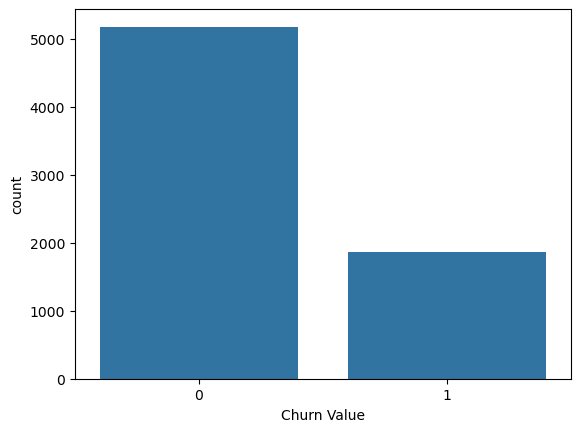

In [30]:
import seaborn as sns
sns.countplot(data=df,x='Churn Value')

> ### Observation -1
~26% customers churned
Dataset is imbalanced

<Axes: xlabel='Tenure Months', ylabel='Count'>

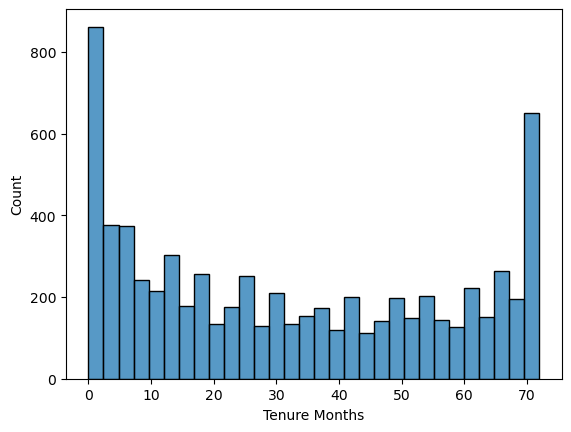

In [31]:
sns.histplot(df['Tenure Months'], bins=30)

### Observation 2: Customer Tenure Distribution

The tenure distribution highlights two distinct customer segments:

- **New customers (0–5 months):** A significant portion of customers fall into this group, indicating that many users leave during the early stage of their subscription.
- **Long-term customers (~70 months):** Another large segment consists of customers who have stayed with the service for a long period, showing strong loyalty.

**Key Insight:**  
Customers tend to follow one of two paths—either they churn early within the first few months or remain loyal for many years once they pass the initial adoption phase. This indicates that the **early customer experience period is critical for retention**.

<Axes: xlabel='Churn Value', ylabel='Monthly Charges'>

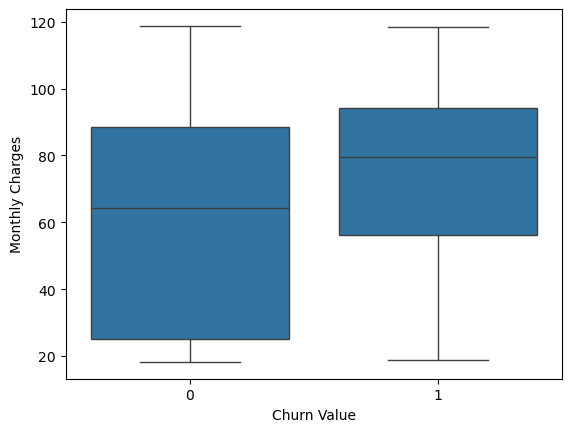

In [32]:
sns.boxplot(x='Churn Value', y='Monthly Charges', data=df)

### Observation 3: Monthly Charges vs Churn

The analysis of monthly charges reveals a clear relationship between pricing and customer churn.

- **Higher monthly charges correlate with higher churn rates.**
- The **median monthly charge for churned customers is approximately $80**, which is notably higher than the **~$65 median for retained customers**.

**Key Insight:**  
Customers paying higher monthly fees appear more likely to leave, suggesting that **pricing pressure or perceived value for money may play a significant role in churn behavior**.

<Axes: xlabel='Churn Value', ylabel='Tenure Months'>

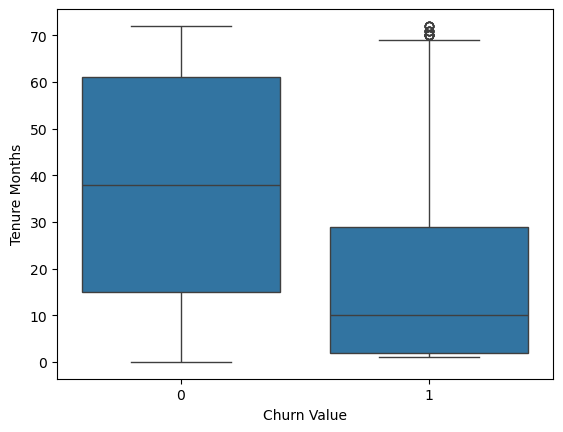

In [33]:
sns.boxplot(x='Churn Value', y='Tenure Months', data=df)

### Boxplot — Tenure vs Churn

**What the chart shows**

- Median tenure for **customers who stayed:** ~38 months  
- Median tenure for **customers who churned:** ~10 months  

**Key Observation**

Customers who churn tend to leave **much earlier** than customers who stay.

**Tenure Spread**

- **Retained customers**
  - Typical tenure ranges from **15 → 60+ months**
  - Indicates a strong base of **long-term loyal customers**

- **Churned customers**
  - Most tenure values fall between **0 → 25 months**
  - Suggests that churn mainly occurs **early in the customer lifecycle**

**Outliers**

A small number of churned customers appear around **~70 months**, showing that long-term customers can still churn, but this is **uncommon**.

**Key Takeaway**

The boxplot clearly indicates that **customers with shorter tenure are significantly more likely to churn**, while customers who stay longer tend to remain loyal.

<Axes: xlabel='Tenure Months', ylabel='Count'>

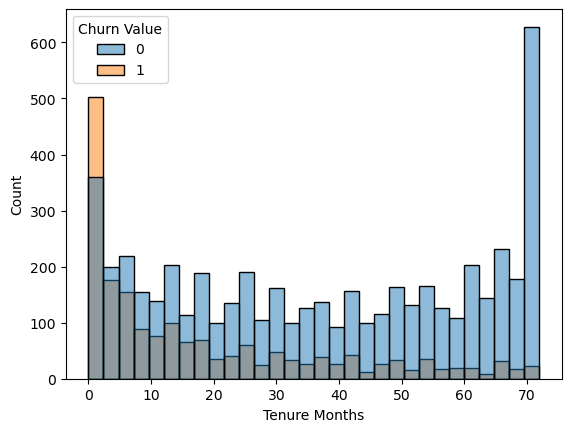

In [34]:
sns.histplot(data=df, x='Tenure Months', hue='Churn Value', bins=30)

### Chart 2: Tenure Distribution by Churn

**What the chart shows**

The tenure distribution highlights how churn behavior changes as customers stay longer with the service.

**Key Patterns**

- A large portion of churn occurs within **0–10 months**
- After **20–30 months**, the frequency of churn **drops significantly**

**Loyal Customer Segment**

A noticeable number of customers have **70+ months of tenure**, representing a group of **highly retained long-term users**.

**Key Insight**

Customers are **most likely to churn within the first 12 months** after joining.

Once customers remain beyond **about 24 months**, the probability of churn **decreases significantly**, indicating stronger loyalty.

**Business Implication**

Improving the **early customer experience and engagement** can help reduce churn and increase long-term retention.

In [35]:
df.head()

,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


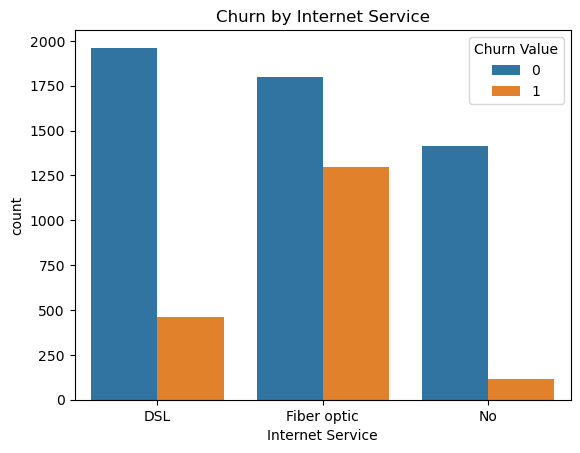

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Internet Service', hue='Churn Value')
plt.title("Churn by Internet Service")
plt.show()

In [37]:
df.groupby('Internet Service')['Churn Value'].value_counts()
pd.crosstab(df['Internet Service'],df['Churn Value'],normalize='index')*100

Churn Value,0,1
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


## 🔍 Observation: Internet Service vs Churn

- Fiber optic users have the highest churn rate (~42%)
- DSL users have moderate churn (~19%)
- Customers with no internet service have the lowest churn (~7%)

---

## 🧠 Insight

Customers with **fiber optic service are more likely to churn** compared to other groups.

---

## ⚡ Conclusion

> Higher-end service users (fiber) show higher churn behavior, while low-usage customers are more stable.

In [38]:
df.groupby('Contract')['Churn Value'].value_counts()
pd.crosstab(df['Contract'],df['Churn Value'],normalize='index')*100

Churn Value,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


## 🔍 Observation: Contract Type vs Churn

- Customers with **month-to-month contracts have the highest churn rate (~42.7%)**
- Customers with **one-year contracts show much lower churn (~11.3%)**
- Customers with **two-year contracts have the lowest churn (~2.8%)**

---

## 🧠 Insight

Customers on **short-term (month-to-month) contracts are significantly more likely to churn**, while long-term contract customers are more stable.

---

## ⚡ Conclusion

> Churn decreases as contract duration increases — long-term commitments improve customer retention.

In [39]:
df.groupby('Gender')['Churn Value'].value_counts()
pd.crosstab(df['Gender'],df['Churn Value'],normalize='index')*100

Churn Value,0,1
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


## 🔍 Observation: Gender vs Churn

- Female customers have a churn rate of ~26.9%  
- Male customers have a churn rate of ~26.2%  

---

## 🧠 Insight

Churn rates are almost identical across genders, indicating that **gender has no significant impact on customer churn**.

---

## ⚡ Conclusion

> Gender is not a key driver of churn and is unlikely to be an important feature for prediction.

In [40]:
df['zip_group'] = pd.qcut(df['Zip Code'], q=5)

pd.crosstab(df['zip_group'], df['Churn Value'], normalize='index') * 100

Churn Value,0,1
zip_group,,
"(90000.999, 91786.0]",74.326241,25.673759
"(91786.0, 92860.0]",72.462740,27.537260
"(92860.0, 94511.0]",74.502841,25.497159
"(94511.0, 95493.0]",73.011364,26.988636
"(95493.0, 96161.0]",73.011364,26.988636


## 🔍 Observation: Zip Group vs Churn

- Churn rates across all zip groups are very similar, ranging between ~25% to ~27.5%  
- No zip group shows a significantly higher or lower churn compared to others  

---

## 🧠 Insight

There is **no strong variation in churn across different zip code groups**, indicating that customer location (at zip level) does not significantly influence churn behavior.

---

## ⚡ Conclusion

> Zip code grouping does not have a meaningful impact on churn and is not a strong predictor for this problem.

Text(0.5, 1.0, 'Churn By payment Method')

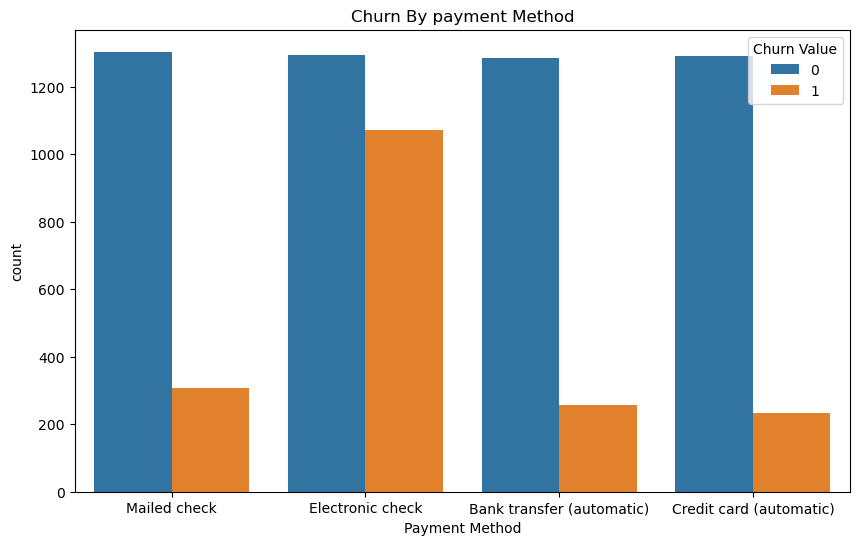

In [41]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Payment Method',hue='Churn Value')
plt.title('Churn By payment Method')

In [42]:
df.groupby('Payment Method')['Churn Value'].value_counts()
pd.crosstab(df['Payment Method'],df['Churn Value'],normalize='index')*100

Churn Value,0,1
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## 🔍 Observation: Payment Method vs Churn

- Customers using **Electronic check have the highest churn rate (~45.3%)**
- Customers using **Bank transfer (~16.7%) and Credit card (~15.2%) show significantly lower churn**
- **Mailed check users have moderate churn (~19.1%)**

---

## 🧠 Insight

Customers paying via **electronic check are much more likely to churn**, while those using **automatic payment methods (bank transfer or credit card)** tend to stay longer.

---

## ⚡ Conclusion

> Automatic payment methods are associated with lower churn, whereas manual payment methods, especially electronic checks, show higher churn behavior.

---
## 🧠 Key Insights

- Customers with **month-to-month contracts** have the highest churn  
- **Fiber optic users** show higher churn compared to other services  
- **Electronic check users** churn more than auto-payment users  
- Customers with **low tenure** are more likely to churn  
- Lack of **tech support and security services** increases churn

---


## ⚙ Feature Engineering

In [43]:
df.head()

,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,zip_group
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,"(90000.999, 91786.0]"
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,"(90000.999, 91786.0]"
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,"(90000.999, 91786.0]"
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,"(90000.999, 91786.0]"
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,"(90000.999, 91786.0]"


In [44]:
'''

Churn rates across different zip groups show minimal variation (~25–27%), indicating no strong relationship between location and churn.

⚡ Decision

 Zip Code and City features were removed as they do not provide meaningful predictive value.Geographical_cols=['City','Zip Code'] '''

geographical_cols=['City','Zip Code']
df.drop(columns=geographical_cols,inplace=True)

In [45]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,zip_group
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,"(90000.999, 91786.0]"
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,"(90000.999, 91786.0]"
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,"(90000.999, 91786.0]"
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,"(90000.999, 91786.0]"
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,"(90000.999, 91786.0]"


In [46]:
categorical_cols.remove('City')

In [47]:
categorical_cols

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Total Charges']

In [48]:
# Total Charges should be numeric
df['Total Charges']=df['Total Charges'].replace(" ",None)
df['Total Charges']=pd.to_numeric(df['Total Charges'])

In [49]:
categorical_cols = list(df.select_dtypes(include='object').columns)
categorical_cols

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

In [50]:
for col in categorical_cols:
    print(df[col].value_counts())

Gender
Male      3555
Female    3488
Name: count, dtype: int64
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     5416
Yes    1627
Name: count, dtype: int64
Phone Service
Yes    6361
No      682
Name: count, dtype: int64
Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
Online Backup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
Device Protection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
Tech Support
No                     3473
Yes                    2044
No internet service    

**Problem:**

- Columns like: Online Security, Tech Support, Device Protection

**Have:**
No internet service
👉 This is redundant with Internet Service = No

In [51]:
service_cols=['Online Security','Online Backup','Device Protection','Tech Support','Streaming Movies','Streaming TV']
for col in service_cols:
    df[col]=df[col].replace('No internet service','No')

In [52]:
df['Multiple Lines'] = df['Multiple Lines'].replace('No phone service', 'No')

In [53]:
for col in categorical_cols:
    print(df[col].value_counts())

Gender
Male      3555
Female    3488
Name: count, dtype: int64
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     5416
Yes    1627
Name: count, dtype: int64
Phone Service
Yes    6361
No      682
Name: count, dtype: int64
Multiple Lines
No     4072
Yes    2971
Name: count, dtype: int64
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
Online Security
No     5024
Yes    2019
Name: count, dtype: int64
Online Backup
No     4614
Yes    2429
Name: count, dtype: int64
Device Protection
No     4621
Yes    2422
Name: count, dtype: int64
Tech Support
No     4999
Yes    2044
Name: count, dtype: int64
Streaming TV
No     4336
Yes    2707
Name: count, dtype: int64
Streaming Movies
No     4311
Yes    2732
Name: count, dtype: int64
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
Paperless Billing
Yes    4

In [54]:
services = [
    'Phone Service','Multiple Lines','Online Security',
    'Online Backup','Device Protection','Tech Support',
    'Streaming TV','Streaming Movies'
]

df['num_services'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

In [55]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'zip_group', 'num_services'],
      dtype='object')

In [56]:
df.describe()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,num_services
count,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2283.300441,0.265370,3.362914
std,24.559481,30.090047,2266.771362,0.441561,2.062031
min,0.000000,18.250000,18.800000,0.000000,0.000000
25%,9.000000,35.500000,401.450000,0.000000,1.000000
50%,29.000000,70.350000,1397.475000,0.000000,3.000000
75%,55.000000,89.850000,3794.737500,1.000000,5.000000
max,72.000000,118.750000,8684.800000,1.000000,8.000000


In [57]:
df['Tenure_group'] = pd.cut(
    df['Tenure Months'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=["0-12", "12-24", "24-48", "48-60", "60-72"]
)

In [58]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,zip_group,num_services,Tenure_group
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,"(90000.999, 91786.0]",3,0-12
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,"(90000.999, 91786.0]",1,0-12
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,"(90000.999, 91786.0]",5,0-12
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,"(90000.999, 91786.0]",6,24-48
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,"(90000.999, 91786.0]",6,48-60


In [59]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [60]:
df['AvgCharges'] = df['Total Charges'] / (df['Tenure Months'] + 1)
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,zip_group,num_services,Tenure_group,AvgCharges
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,"(90000.999, 91786.0]",3,0-12,36.050000
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,"(90000.999, 91786.0]",1,0-12,50.550000
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,"(90000.999, 91786.0]",5,0-12,91.166667
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,"(90000.999, 91786.0]",6,24-48,105.036207
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,"(90000.999, 91786.0]",6,48-60,100.726000


In [61]:
df['HighRisk_Combo'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['Monthly Charges'] > 70)
).astype(int)

In [62]:
df['ServiceIntensity'] = df['num_services'] / (df['Tenure Months'] + 1)

In [63]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,zip_group,num_services,Tenure_group,AvgCharges,HighRisk_Combo,ServiceIntensity
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,"(90000.999, 91786.0]",3,0-12,36.050000,0,1.000000
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,"(90000.999, 91786.0]",1,0-12,50.550000,1,0.333333
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,"(90000.999, 91786.0]",5,0-12,91.166667,1,0.555556
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,"(90000.999, 91786.0]",6,24-48,105.036207,1,0.206897
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,"(90000.999, 91786.0]",6,48-60,100.726000,1,0.120000


In [64]:
df['zip_group'].value_counts()

zip_group
(90000.999, 91786.0]    1410
(91786.0, 92860.0]      1409
(92860.0, 94511.0]      1408
(94511.0, 95493.0]      1408
(95493.0, 96161.0]      1408
Name: count, dtype: int64

In [65]:
categorical_cols = list(df.select_dtypes(include='object').columns)
categorical_cols

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

In [66]:
df.dtypes

Gender                 object
Senior Citizen         object
Partner                object
Dependents             object
Tenure Months           int64
Phone Service          object
Multiple Lines         object
Internet Service       object
Online Security        object
Online Backup          object
Device Protection      object
Tech Support           object
Streaming TV           object
Streaming Movies       object
Contract               object
Paperless Billing      object
Payment Method         object
Monthly Charges       float64
Total Charges         float64
Churn Value             int64
zip_group            category
num_services            int64
Tenure_group         category
AvgCharges            float64
HighRisk_Combo          int32
ServiceIntensity      float64
dtype: object

In [67]:
numerical_cols = list(df.select_dtypes(include=['int64','float64']).columns)
numerical_cols.remove('Churn Value')


---

## ✂ Train And Test Split


In [68]:
# 1 split data
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

---

## 🔧 Preprocessing PipeLine

In [69]:
# ===============================
# Build Preprocessing Pipeline
# ===============================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Binary features you do NOT want scaled
binary_cols = ['HighRisk_Combo']

# Remove binary cols from numerical cols
numerical_cols = [col for col in numerical_cols if col not in binary_cols]

# Add binary cols to categorical cols so they are retained
categorical_cols = categorical_cols + binary_cols

# Numeric pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical / binary pipeline
onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop='if_binary'))
])

# Column transformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("ohe", onehot_pipeline, categorical_cols)
])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


---

## 🤖Logistic Regression Model Training (Base Model)

In [70]:
# ===============================
# Logistic Regression Baseline
# ===============================
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic pipeline created.")

Logistic pipeline created.


In [71]:
# Train Logistic Regression
logistic_model.fit(X_train, y_train)

print("Logistic model trained.")

Logistic model trained.


In [72]:
print(df.columns.tolist())

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'zip_group', 'num_services', 'Tenure_group', 'AvgCharges', 'HighRisk_Combo', 'ServiceIntensity']


### Logistic Model Evaluation

In [73]:
from sklearn.metrics import classification_report, roc_auc_score , average_precision_score

# Predict probabilities
y_probs_log = logistic_model.predict_proba(X_test)[:, 1]

# Default threshold 0.5
y_pred_log = (y_probs_log >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_probs_log))
print("PR-AUC:", average_precision_score(y_test, y_probs_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

ROC-AUC: 0.8540106951871659
PR-AUC: 0.671985602150715

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



### Get feature names from the preprocessor

In [74]:

# feature names after preprocessing
feature_names = logistic_model.named_steps['preprocessor'].get_feature_names_out()

# logistic regression weights
weights = logistic_model.named_steps['classifier'].coef_[0]

# combine into dataframe
coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": weights
})

# sort by weight descending
coef_df = coef_df.sort_values(by="weight", ascending=False)

print(coef_df)

                                          feature    weight
13              ohe__Internet Service_Fiber optic  1.123411
21                   ohe__Contract_Month-to-month  0.801947
1                            num__Monthly Charges  0.358032
2                              num__Total Charges  0.337572
24                     ohe__Paperless Billing_Yes  0.317401
20                      ohe__Streaming Movies_Yes  0.311963
8                                ohe__Partner_Yes  0.309760
3                               num__num_services  0.304540
19                          ohe__Streaming TV_Yes  0.290132
11                        ohe__Multiple Lines_Yes  0.279486
27           ohe__Payment Method_Electronic check  0.194683
5                           num__ServiceIntensity  0.068964
7                         ohe__Senior Citizen_Yes  0.030804
6                                ohe__Gender_Male  0.022047
17                     ohe__Device Protection_Yes -0.084298
25  ohe__Payment Method_Bank transfer (a

In [75]:
print(logistic_model.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Tenure Months', 'Monthly Charges',
                                  'Total Charges', 'num_services', 'AvgCharges',
                                  'ServiceIntensity']),
                                ('ohe',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'))]),
                                 ['Gender', 'Senior Citizen', 'Partner',
       

In [76]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# 1) split fitted pipeline into parts
preprocessor = logistic_model.named_steps['preprocessor']
classifier = logistic_model.named_steps['classifier']

# 2) transform data using the fitted preprocessor
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# 3) get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# 4) convert transformed matrices to DataFrames for cleaner SHAP plots
X_train_trans_df = pd.DataFrame(
    X_train_trans,
    columns=feature_names,
    index=X_train.index
)

X_test_trans_df = pd.DataFrame(
    X_test_trans,
    columns=feature_names,
    index=X_test.index
)

# 5) build SHAP explainer for logistic regression
explainer = shap.LinearExplainer(classifier, X_train_trans_df)

# 6) compute SHAP values for test set
shap_values = explainer(X_test_trans_df)

print("SHAP values shape:", shap_values.values.shape)

c:\Users\NIHAR\anaconda3\envs\ml_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (1409, 30)


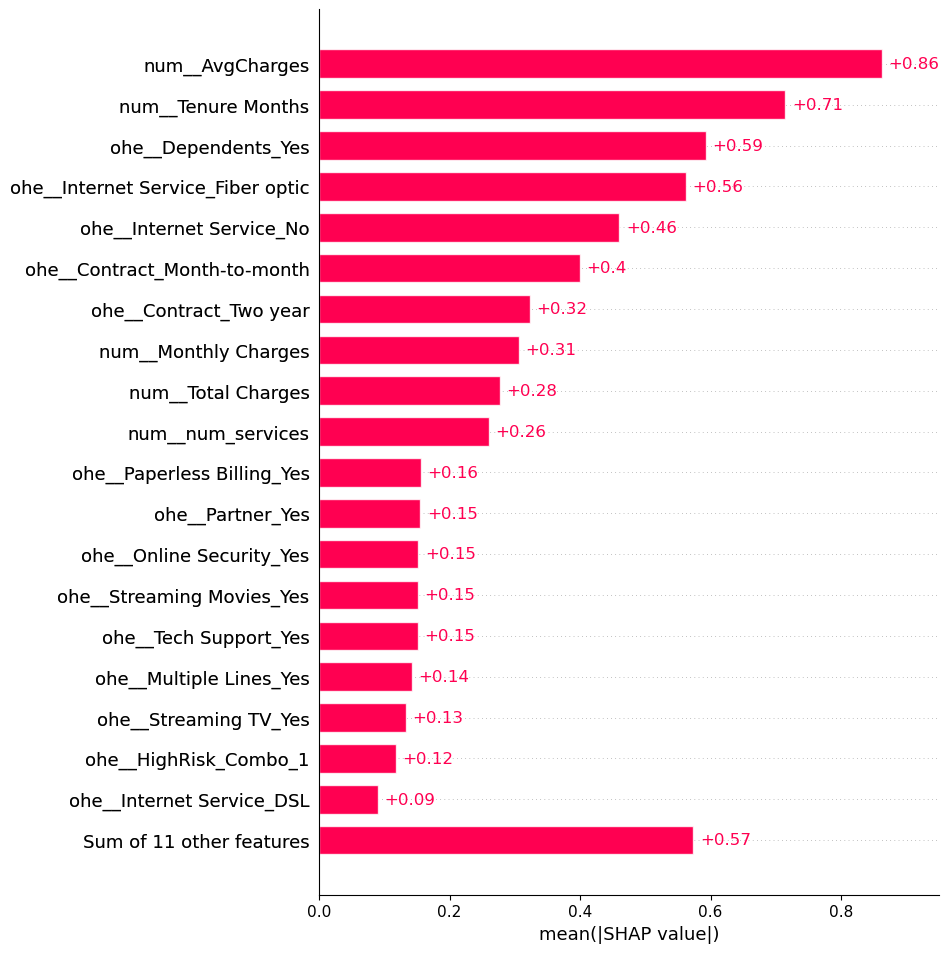

In [77]:
shap.plots.bar(shap_values, max_display=20)

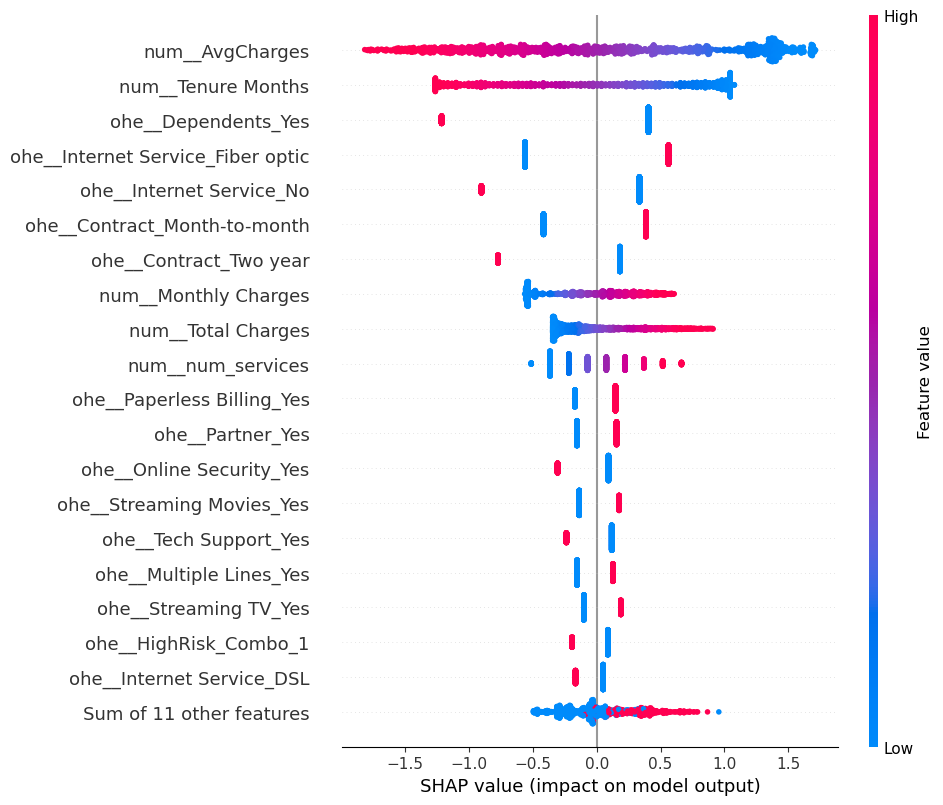

In [78]:
shap.plots.beeswarm(shap_values, max_display=20)

In [79]:
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print(shap_importance.head(20))

                                 feature  mean_abs_shap
4                        num__AvgCharges       0.862293
0                     num__Tenure Months       0.714545
9                    ohe__Dependents_Yes       0.592331
13     ohe__Internet Service_Fiber optic       0.561705
14              ohe__Internet Service_No       0.460173
21          ohe__Contract_Month-to-month       0.399414
23                ohe__Contract_Two year       0.322600
1                   num__Monthly Charges       0.306227
2                     num__Total Charges       0.277025
3                      num__num_services       0.260436
24            ohe__Paperless Billing_Yes       0.156259
8                       ohe__Partner_Yes       0.154880
15              ohe__Online Security_Yes       0.152027
20             ohe__Streaming Movies_Yes       0.151319
18                 ohe__Tech Support_Yes       0.151011
11               ohe__Multiple Lines_Yes       0.142193
19                 ohe__Streaming TV_Yes       0

In [80]:
shap_importance["feature"] = (
    shap_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("ohe__", "", regex=False)
)

print(shap_importance.head(20))

                            feature  mean_abs_shap
4                        AvgCharges       0.862293
0                     Tenure Months       0.714545
9                    Dependents_Yes       0.592331
13     Internet Service_Fiber optic       0.561705
14              Internet Service_No       0.460173
21          Contract_Month-to-month       0.399414
23                Contract_Two year       0.322600
1                   Monthly Charges       0.306227
2                     Total Charges       0.277025
3                      num_services       0.260436
24            Paperless Billing_Yes       0.156259
8                       Partner_Yes       0.154880
15              Online Security_Yes       0.152027
20             Streaming Movies_Yes       0.151319
18                 Tech Support_Yes       0.151011
11               Multiple Lines_Yes       0.142193
19                 Streaming TV_Yes       0.133236
29                 HighRisk_Combo_1       0.117704
12             Internet Service

### Logistic Model Tuning

In [81]:
from sklearn.model_selection import GridSearchCV

# parameter grid for the classifier inside the pipeline
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(
    estimator=logistic_model,      # your full pipeline
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best Params: {'classifier__C': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV ROC-AUC: 0.8610093088647683


In [82]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

best_model = grid_search.best_estimator_

y_probs = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.5).astype(int)

print("Test ROC-AUC:", roc_auc_score(y_test, y_probs))
print("Test PR-AUC:", average_precision_score(y_test, y_probs))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test ROC-AUC: 0.8525795034746442
Test PR-AUC: 0.668432873936363

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [83]:
from sklearn.model_selection import cross_validate

scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'f1': 'f1'
}

cv_results = cross_validate(
    logistic_model,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("ROC-AUC:", cv_results['test_roc_auc'].mean())
print("PR-AUC:", cv_results['test_pr_auc'].mean())
print("F1:", cv_results['test_f1'].mean())

ROC-AUC: 0.8593074234141926
PR-AUC: 0.6835547056170912
F1: 0.6349359510029224


# 📊 Logistic Model Summary

## 🔥 Model Performance

- **ROC-AUC:** 0.85 (strong discrimination)
- **PR-AUC:** 0.67 (good for imbalanced data)
- **Recall (Churn):** 0.78 (captures most churners)
- **Precision (Churn):** 0.52
- **Accuracy:** 0.75  
- **Cross-Validation ROC-AUC:** 0.86 (stable)
- **Best Model:** Logistic Regression (L1, C=1)

---

## 📈 Key Business Insights

### 🚨 High Churn Risk
- Fiber optic users
- Month-to-month contracts
- High monthly and total charges
- Paperless billing
- Customers with more services

### 🧊 Low Churn (Retention Signals)
- Long tenure customers
- Two-year contracts
- Customers with dependents
- No internet service users

---

## 🔍 Model Behavior

- Model optimized for **high recall (0.78)**  
- Focus: **catch churners early**
- Accepts moderate false positives for better retention targeting

---

## 🧠 SHAP Explainability Insights

Top influencing features:
- AvgCharges
- Tenure Months
- Dependents
- Internet Service (Fiber optic)
- Contract type

- Model is **interpretable and aligned with business logic**

---

## ⚙️ Optimization Steps

- Feature engineering (AvgCharges, num_services, tenure groups)
- Proper preprocessing (imputation, scaling, encoding)
- Handled class imbalance (`class_weight='balanced'`)
- Hyperparameter tuning (GridSearchCV)
- Cross-validation for robustness

---

## 🚀 Final Verdict for our base model(Logisitc regression)

- Strong predictive performance with **ROC-AUC ~0.86**
- Interpretable model suitable for business use
- Ready for deployment in churn prediction & retention strategy

---



---


## 🤖LightGBM Model classifier 

In [84]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgboost_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',   # required to suppress warning
        random_state=42
    ))
])

xgboost_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ohe', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [85]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_probs = xgboost_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_probs))
print("PR-AUC:", average_precision_score(y_test, y_probs))

ROC-AUC: 0.8390090159911131
PR-AUC: 0.6295947667978232


In [86]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

# class imbalance weight
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# pipeline
xgboost_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ))
])

# parameter grid
param_grid = {
    "classifier__n_estimators": [100, 300, 500],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=xgboost_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train)

print("Best Params:", grid_search_xgb.best_params_)
print("Best CV ROC-AUC:", grid_search_xgb.best_score_)

best_xgb = grid_search_xgb.best_estimator_

# test set evaluation
y_probs_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_probs_xgb >= 0.5).astype(int)

print("Test ROC-AUC:", roc_auc_score(y_test, y_probs_xgb))
print("Test PR-AUC:", average_precision_score(y_test, y_probs_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Params: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 500, 'classifier__subsample': 0.8}
Best CV ROC-AUC: 0.8641681559064635
Test ROC-AUC: 0.8534565604898086
Test PR-AUC: 0.6703445247101112

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [87]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_probs_log >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    results.append((t, f1))

best_t = max(results, key=lambda x: x[1])
print("Best threshold:", best_t)

Best threshold: (0.6000000000000002, 0.6350710900473934)


In [88]:
# top 20% risky customers
top_k = int(0.2 * len(y_probs_log))

top_idx = np.argsort(y_probs_log)[-top_k:]

capture_rate = y_test.iloc[top_idx].mean()

print("Churn captured in top 20%:", capture_rate)

Churn captured in top 20%: 0.693950177935943


In [89]:
# overall churn rate
print(y_test.mean())

0.2654364797728886


In [90]:
from sklearn.metrics import precision_score, recall_score

for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_probs_log >= t).astype(int)
    print(f"\nThreshold: {t}")
    print("Precision:", precision_score(y_test, y_pred_t))
    print("Recall:", recall_score(y_test, y_pred_t))


Threshold: 0.3
Precision: 0.43918053777208704
Recall: 0.9171122994652406

Threshold: 0.4
Precision: 0.4771048744460857
Recall: 0.8636363636363636

Threshold: 0.5
Precision: 0.5168141592920354
Recall: 0.7807486631016043

Threshold: 0.6
Precision: 0.5702127659574469
Recall: 0.7165775401069518


In [91]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,zip_group,num_services,Tenure_group,AvgCharges,HighRisk_Combo,ServiceIntensity
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,"(90000.999, 91786.0]",3,0-12,36.050000,0,1.000000
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,"(90000.999, 91786.0]",1,0-12,50.550000,1,0.333333
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,"(90000.999, 91786.0]",5,0-12,91.166667,1,0.555556
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,"(90000.999, 91786.0]",6,24-48,105.036207,1,0.206897
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,"(90000.999, 91786.0]",6,48-60,100.726000,1,0.120000


# 💼 Telco Customer Churn Prediction — Business-Driven ML System

---

## 🧠 Problem

Customer churn reduces revenue.  
Goal: **predict high-risk customers and optimize retention strategy**, not just build a model.

---

# 📊 Dataset

- Total customers: **7,043**
- Churn rate: **26.5%**
- Imbalanced classification problem

---

# ⚙️ Model Performance

- **ROC-AUC:** 0.85  
- **PR-AUC:** 0.67  
- **Recall (Churn):** 0.78  
- **Precision (Churn):** 0.52  
- **Cross-validated ROC-AUC:** 0.86  

👉 Model is **stable and production-ready**

---

# 🎯 Threshold Optimization (Critical)

| Threshold | Precision | Recall |
|----------|----------|--------|
| 0.3 | 0.44 | **0.92** |
| 0.4 | 0.48 | 0.86 |
| 0.5 | 0.52 | 0.78 |
| 0.6 | **0.57** | 0.72 |

### Insight:
- Lower threshold → higher recall → better churn capture  
- Higher threshold → better precision → fewer wasted actions  

👉 **Optimal depends on business goal, not model**

---

# 💰 Business Simulation (THIS IS THE DIFFERENCE)

## 🎯 Strategy: Target Top 20% High-Risk Customers

- Captured churners: **~69%**
- Baseline churn rate: **26.5%**

### 📈 Lift Calculation

\[
Lift = \frac{0.69}{0.265} \approx 2.6
\]

👉 Model is **2.6× better than random targeting**

---

## 💸 Cost vs Benefit (Assumed)

- Contact cost = 1 unit  
- Retention value = 5 units  

### Result:
- Targeting all users → wasteful  
- Targeting top 20% → **high ROI segment**

👉 Model enables **cost-efficient retention campaigns**

---

# 🔍 Key Drivers of Churn

## 🚨 High Risk
- Month-to-month contracts  
- Fiber optic users  
- High monthly charges  
- Paperless billing  

## 🧊 Low Risk
- Long tenure  
- Two-year contracts  
- Customers with dependents  

👉 Model insights align with **real-world business logic**

---

# ⚙️ Approach

### Data Processing
- Cleaned TotalCharges
- Encoded categorical features
- Scaled numeric features

### Feature Engineering
- AvgCharges → spending behavior  
- num_services → engagement  
- HighRisk_Combo → interaction signal  
- ServiceIntensity → usage per tenure  

### Modeling
- Logistic Regression (final)
- XGBoost tested → no significant gain

### Optimization
- GridSearchCV tuning  
- Stratified cross-validation  
- Threshold tuning (business-driven)

---

# 🧠 Key Insight (Important)

- Problem is **largely linearly separable**
- Logistic Regression ≈ XGBoost performance
- Feature engineering > model complexity

👉 Focus shifted from **model building → decision optimization**

---

# 🚀 Decision Framework

| Risk Segment | Action |
|-------------|--------|
| High Risk | Discounts, retention calls |
| Medium Risk | Engagement campaigns |
| Low Risk | No action (cost saving) |

---

# ⚠️ Limitations

- No customer lifetime value (CLV)
- No cost-sensitive optimization in training
- No time-series or behavioral features
- Static dataset (no real-time updates)

---

# 🔥 Next Steps (What top candidates do)

- Profit-based threshold optimization  
- CLV-based prioritization  
- Uplift modeling (who will respond to retention)  
- Real-time scoring pipeline  

---

# 💀 Final Conclusion

Built a churn prediction system achieving **~0.85 ROC-AUC**, and transformed predictions into actionable business strategy.  
By targeting the top 20% high-risk customers, the model captures **~69% of churners**, delivering **2.6× improvement over random targeting** and enabling cost-efficient retention.

---



---

### business assumptions

In [92]:
# Business assumptions
cost_contact = 1        # cost to contact 1 customer
value_saved = 5         # revenue if churn is prevented

### Profit Calculation Function

In [93]:
import numpy as np

def calculate_profit(y_true, y_probs, threshold, cost, value):
    y_pred = (y_probs >= threshold).astype(int)

    profit = 0
    for i in range(len(y_true)):
        if y_pred[i] == 1:  # we target this customer
            profit -= cost  # cost to contact
            
            if y_true.iloc[i] == 1:  # actually churned
                profit += value  # saved revenue
    
    return profit

### Find BEST threshold (profit-based)

In [94]:
thresholds = np.arange(0.1, 0.9, 0.05)

profits = []

for t in thresholds:
    p = calculate_profit(y_test, y_probs_log, t, cost_contact, value_saved)
    profits.append((t, p))

best_profit = max(profits, key=lambda x: x[1])

print("Best threshold (profit):", best_profit)

Best threshold (profit): (0.3500000000000001, 959)


In [95]:
default_profit = calculate_profit(y_test, y_probs_log, 0.5, cost_contact, value_saved)

print("Profit at threshold 0.5:", default_profit)
print("Best possible profit:", best_profit[1])

Profit at threshold 0.5: 895
Best possible profit: 959


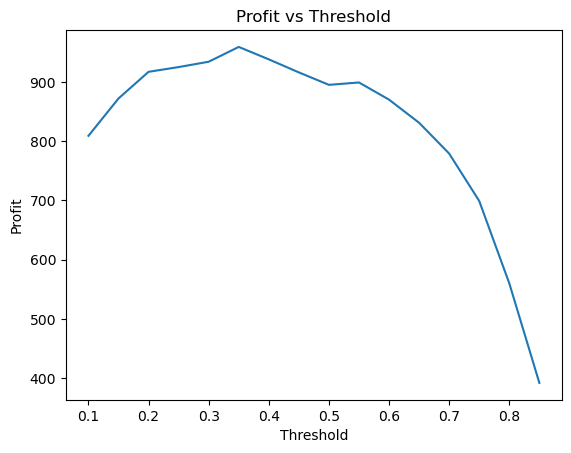

In [96]:
import matplotlib.pyplot as plt

thresholds_plot = [x[0] for x in profits]
profits_plot = [x[1] for x in profits]

plt.plot(thresholds_plot, profits_plot)
plt.xlabel("Threshold")
plt.ylabel("Profit")
plt.title("Profit vs Threshold")
plt.show()

## 💰 Profit Optimization (Key Contribution)

Instead of using the default threshold (0.5), the model was optimized for **maximum business profit**.

### Assumptions:
- Cost to contact a customer = 1 unit  
- Revenue saved per retained customer = 5 units  

### Results:
- Profit at default threshold (0.5): **895**
- Maximum achievable profit: **959**
- Optimal threshold: **0.35**

### Impact:
- **~7% increase in profit** compared to default model behavior  
- Demonstrates that threshold selection is a **business decision, not a modeling default**

